<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/14_priority_final_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 14 Final Priority Model Pipeline

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook builds the final production priority classification pipeline, combining TF-IDF text features, n-grams, temporal features (day-of-week, month), and class-weighted Random Forest — the best-performing configuration identified in Notebook 13.

## Mounting Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [3]:
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Importing and preparing the data

We load the cleaned dataset directly (not the pre-saved arrays), since this pipeline needs both text and date columns together.

In [4]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

dataset = pd.read_csv(f'{processed_dir}/swansea_cleaned.csv')
dataset['date_received'] = pd.to_datetime(dataset['date_received'], errors='coerce')
dataset = dataset.dropna(subset=['priority', 'date_received'])

dataset['day_of_week'] = dataset['date_received'].dt.dayofweek
dataset['month'] = dataset['date_received'].dt.month

print("Total rows:", len(dataset))
dataset[['request_text', 'day_of_week', 'month', 'priority']].head()

Total rows: 254377


,request_text,day_of_week,month,priority
0,Live Rat in House * Urgent* Animal Warden - Ou...,5,1,HIGH
1,Recycling Multiple Bag & Liner Request,5,1,LOW
2,Recycling Multiple Bag & Liner Request,5,1,LOW
3,Domestic Bulk Request,5,1,LOW
4,"General Rubbish/hous,building",5,1,MEDIUM


## Splitting into Training and Test sets

In [5]:
from sklearn.model_selection import train_test_split

X = dataset[['request_text', 'day_of_week', 'month']]
y = dataset['priority'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 203501
Test set size: 50876


## Building a combined pipeline for text and numeric features

We use ColumnTransformer to apply TF-IDF only to the text column, while passing the numeric columns through unchanged, all within a single reusable pipeline.

In [6]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1500, ngram_range=(1, 2)), 'request_text'),
        ('temporal', 'passthrough', ['day_of_week', 'month'])
    ]
)

priority_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1, class_weight='balanced'))
])

priority_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=1500,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'request_text'),
                                                 ('temporal', 'passthrough',
                                                  ['day_of_week', 'month'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=0))])

## Evaluating the final pipeline

In [7]:
y_pred = priority_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.676409308907933

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.57      0.62      0.60     13009
         LOW       0.82      0.75      0.78     24066
      MEDIUM       0.57      0.60      0.58     13801

    accuracy                           0.68     50876
   macro avg       0.65      0.66      0.65     50876
weighted avg       0.69      0.68      0.68     50876



## Visualising the Confusion Matrix

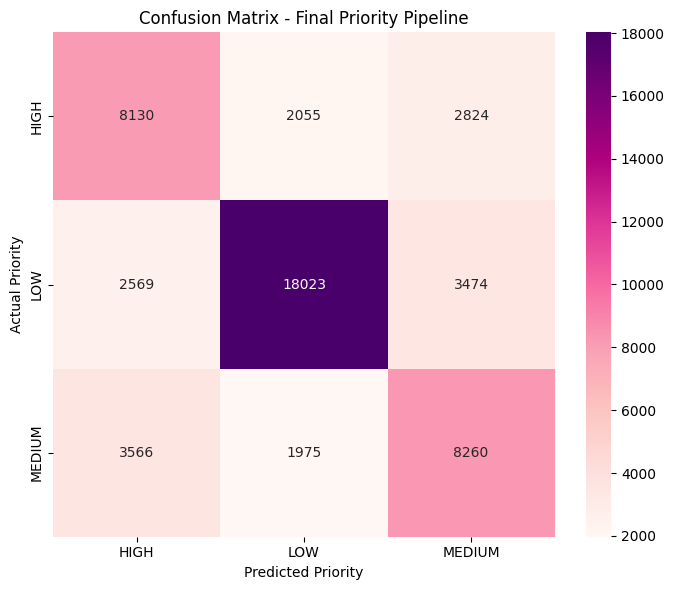

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
unique_labels = sorted(set(y_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - Final Priority Pipeline')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

## Testing the pipeline with a new, unseen example

A quick sanity check to confirm the pipeline works end-to-end on a single new request, exactly as the dashboard will use it.

In [9]:
new_request = pd.DataFrame({
    'request_text': ['live rat in house urgent'],
    'day_of_week': [1],  # Tuesday
    'month': [6]         # June
})

prediction = priority_pipeline.predict(new_request)
print("Predicted priority:", prediction[0])

Predicted priority: HIGH


## Saving the final priority pipeline

In [11]:
models_dir = '/content/drive/MyDrive/council-classifier/models'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(priority_pipeline, f'{models_dir}/priority_pipeline_final.pkl')
print("Final priority pipeline saved to:", models_dir)

Final priority pipeline saved to: /content/drive/MyDrive/council-classifier/models
